In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/amazon_reviews_cleaned.csv",
    parse_dates=["timestamp"]
)

# sécurité : timestamps sans timezone
df["timestamp"] = df["timestamp"].dt.tz_localize(None)


In [2]:
df["hour"] = df["timestamp"].dt.hour


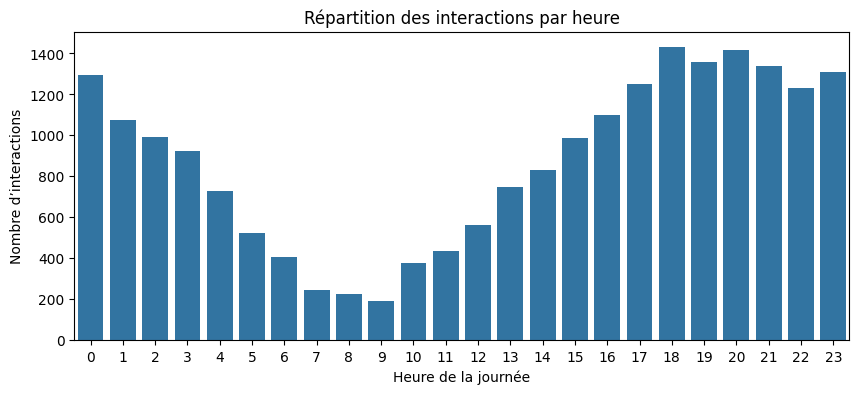

In [3]:
plt.figure(figsize=(10,4))
sns.countplot(x="hour", data=df)
plt.title("Répartition des interactions par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d’interactions")
plt.show()


In [4]:
user_hour_profile = df.groupby("user_id")["hour"].mean().reset_index(
    name="avg_active_hour"
)

user_hour_profile.head()


,user_id,avg_active_hour
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,14.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,16.000000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,15.111111
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,5.666667


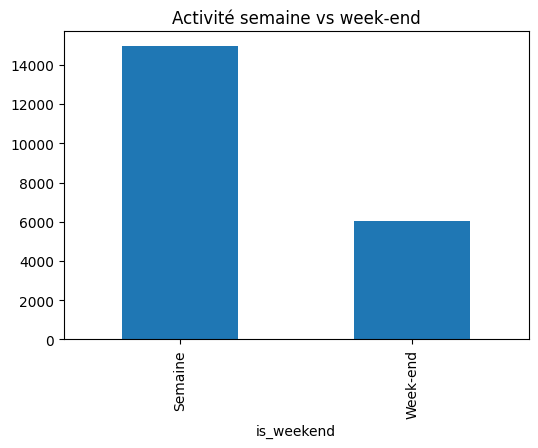

In [5]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"] >= 5
plt.figure(figsize=(6,4))
df["is_weekend"].value_counts().rename(
    {False: "Semaine", True: "Week-end"}
).plot(kind="bar")
plt.title("Activité semaine vs week-end")
plt.show()


In [6]:
user_weekend_ratio = df.groupby("user_id")["is_weekend"].mean().reset_index(
    name="weekend_activity_ratio"
)

user_weekend_ratio.head()


,user_id,weekend_activity_ratio
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,0.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,0.000000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,0.333333
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,0.000000


In [7]:
user_long_term = (
    df.groupby("user_id")["parent_asin"]
      .value_counts(normalize=True)
      .groupby("user_id")
      .head(5)
      .reset_index(name="long_term_pref_weight")
)

user_long_term.head()


,user_id,parent_asin,long_term_pref_weight
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,B00PUTIJQI,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,B000005RDY,1.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,B076HHYNMC,0.500000
3,AE246WPAV4HBLUOOOKTECTYQ7ZPA,B09F5VMN3X,0.500000
4,AE25NQAZI3725GZIL5FS52ZIKWKQ,B001G7L2Y4,0.111111


In [8]:
N = 5

recent_df = (
    df.sort_values("timestamp")
      .groupby("user_id")
      .tail(N)
)

user_short_term = (
    recent_df.groupby("user_id")["parent_asin"]
             .value_counts(normalize=True)
             .reset_index(name="short_term_pref_weight")
)

user_short_term.head()


,user_id,parent_asin,short_term_pref_weight
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,B00PUTIJQI,1.0
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,B000005RDY,1.0
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,B076HHYNMC,0.5
3,AE246WPAV4HBLUOOOKTECTYQ7ZPA,B09F5VMN3X,0.5
4,AE25NQAZI3725GZIL5FS52ZIKWKQ,B004N63SQU,0.2


In [9]:
user_temporal_features = (
    user_hour_profile
    .merge(user_weekend_ratio, on="user_id", how="left")
)

user_temporal_features.head()


,user_id,avg_active_hour,weekend_activity_ratio
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1.000000,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,14.000000,0.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,16.000000,0.000000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,15.111111,0.333333
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,5.666667,0.000000


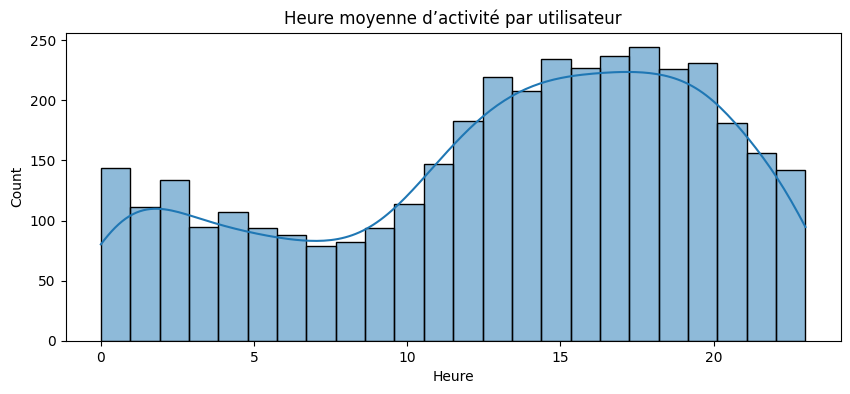

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(user_temporal_features["avg_active_hour"], bins=24, kde=True)
plt.title("Heure moyenne d’activité par utilisateur")
plt.xlabel("Heure")
plt.show()


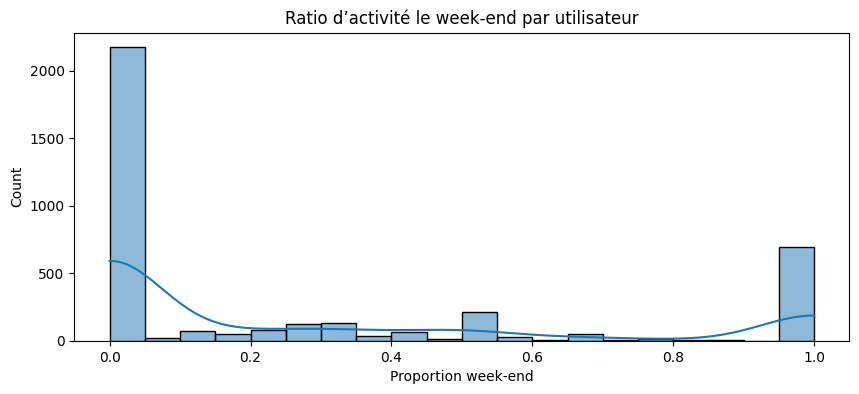

In [11]:
plt.figure(figsize=(10,4))
sns.histplot(user_temporal_features["weekend_activity_ratio"], bins=20, kde=True)
plt.title("Ratio d’activité le week-end par utilisateur")
plt.xlabel("Proportion week-end")
plt.show()


In [12]:
df.to_csv("../data/processed/user_temporal_features.csv", index=False)
